# Investigating a Deployed ML Model via API

- Author: Kim Hummel, Denise Case
- Date: 2026-06
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species


## M7. Investigating a Deployed Model

This notebook calls a live prediction API and hits it systematically.
The model is already trained and served. 

## M7. Probing a Model from the Outside

Once a model is deployed, you cannot always see inside it.
But you can learn a great deal by asking it questions systematically:

- **Vary one feature at a time** and watch predictions change.
  This reveals which inputs the model is most sensitive to.
- **Test edge cases** - try values outside the training range, missing fields,
  extreme numbers and observe how the API responds.
- **Build a prediction grid** over two features at once and visualize
  the decision boundary as a heatmap.


## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

# CUSTOM: update this URL if you deploy your own model.
API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-08-12 09:07:24 | INFO | M07 | === RUN START ===
2026-08-12 09:07:24 | INFO | M07 | project=M07
2026-08-12 09:07:24 | INFO | M07 | repo_dir=ml-07-applied
2026-08-12 09:07:24 | INFO | M07 | python=3.14.3
2026-08-12 09:07:24 | INFO | M07 | os=Windows 11
2026-08-12 09:07:24 | INFO | M07 | shell=powershell
2026-08-12 09:07:24 | INFO | M07 | cwd=notebooks
2026-08-12 09:07:24 | INFO | M07 | github_actions=False
2026-08-12 09:07:24 | INFO | M07 | Confirming installation:
2026-08-12 09:07:24 | INFO | M07 |   python:       3.14.3
2026-08-12 09:07:24 | INFO | M07 |   pandas:       3.0.5
2026-08-12 09:07:24 | INFO | M07 |   numpy:        2.5.2
2026-08-12 09:07:24 | INFO | M07 |   matplotlib:   3.11.1
2026-08-12 09:07:24 | INFO | M07 |   seaborn:      0.13.2
2026-08-12 09:07:24 | INFO | M07 |   requests:     2.34.2
2026-08-12 09:07:24 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict


## Section 2. Baseline Predictions

```text
ANALYST CHOICE
Before investigating, confirm the API returns expected results for
known inputs. If these baseline calls fail, the investigation cannot proceed.
```

In [3]:
# === Section 2. Baseline Predictions ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo"]

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-08-12 09:08:59 | INFO | M07 | Baseline predictions:
2026-08-12 09:08:59 | INFO | M07 |   expected=Adelie     got=Adelie     [OK]
2026-08-12 09:09:00 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  [OK]
2026-08-12 09:09:01 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]


## Section 3. Feature Sensitivity

```text
ANALYST CHOICE
Vary one feature at a time while holding others fixed.
Observe where the prediction changes. That boundary is the model's
decision for that feature. Decide which features matter most.
```

2026-08-13 18:46:45 | INFO | M07 | bill_length_mm sweep:
2026-08-13 18:46:45 | INFO | M07 |  bill_length_mm prediction
      30.000000     Adelie
      31.578947     Adelie
      33.157895     Adelie
      34.736842     Adelie
      36.315789     Adelie
      37.894737     Adelie
      39.473684     Adelie
      41.052632     Adelie
      42.631579  Chinstrap
      44.210526  Chinstrap
      45.789474  Chinstrap
      47.368421  Chinstrap
      48.947368  Chinstrap
      50.526316  Chinstrap
      52.105263  Chinstrap
      53.684211  Chinstrap
      55.263158  Chinstrap
      56.842105  Chinstrap
      58.421053  Chinstrap
      60.000000  Chinstrap


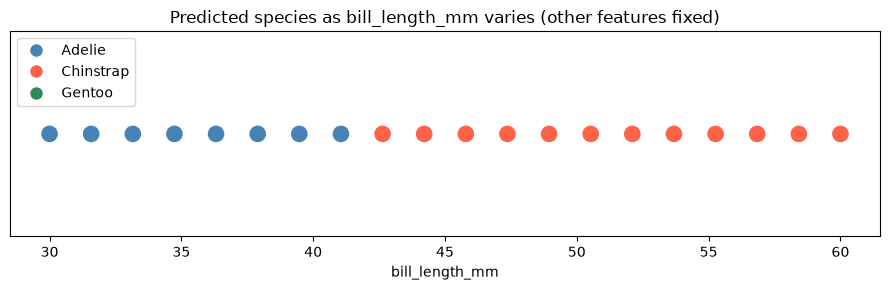

2026-08-13 18:46:46 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [20]:
# === Section 3. Feature Sensitivity ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep bill_length_mm.
BASE: dict[str, Any] = BASELINES[0]
bill_lengths = list(np.linspace(30, 60, 20))
df_sweep = sweep_feature(BASE, "bill_length_mm", bill_lengths)

LOG.info("bill_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["bill_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("bill_length_mm")
plt.yticks([])
plt.title("Predicted species as bill_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

2026-08-12 15:39:33 | INFO | M07 | flipper_length_mm sweep:
2026-08-12 15:39:33 | INFO | M07 |  flipper_length_mm prediction
        170.000000     Adelie
        171.224490     Adelie
        172.448980     Adelie
        173.673469     Adelie
        174.897959     Adelie
        176.122449     Adelie
        177.346939     Adelie
        178.571429     Adelie
        179.795918     Adelie
        181.020408     Adelie
        182.244898     Adelie
        183.469388     Adelie
        184.693878     Adelie
        185.918367     Adelie
        187.142857     Adelie
        188.367347     Adelie
        189.591837     Adelie
        190.816327     Adelie
        192.040816     Adelie
        193.265306     Adelie
        194.489796     Adelie
        195.714286     Adelie
        196.938776     Adelie
        198.163265     Adelie
        199.387755     Adelie
        200.612245     Adelie
        201.836735     Adelie
        203.061224     Adelie
        204.285714     Adelie
     

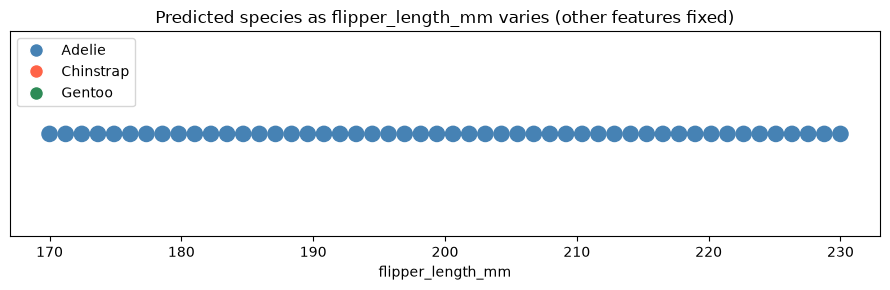

2026-08-12 15:39:33 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [13]:
def sweep_feature2(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep flipper_length_mm.
BASE: dict[str, Any] = BASELINES[0]
flipper_length = list(np.linspace(170, 230, 50))
df_sweep = sweep_feature2(BASE, "flipper_length_mm", flipper_length)

LOG.info("flipper_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["flipper_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("flipper_length_mm")
plt.yticks([])
plt.title("Predicted species as flipper_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

2026-08-12 15:38:56 | INFO | M07 | body_mass_g sweep:
2026-08-12 15:38:56 | INFO | M07 |  body_mass_g prediction
 2700.000000     Adelie
 2773.469388     Adelie
 2846.938776     Adelie
 2920.408163     Adelie
 2993.877551     Adelie
 3067.346939     Adelie
 3140.816327     Adelie
 3214.285714     Adelie
 3287.755102     Adelie
 3361.224490     Adelie
 3434.693878     Adelie
 3508.163265     Adelie
 3581.632653     Adelie
 3655.102041     Adelie
 3728.571429     Adelie
 3802.040816     Adelie
 3875.510204     Adelie
 3948.979592     Adelie
 4022.448980     Adelie
 4095.918367     Adelie
 4169.387755     Adelie
 4242.857143     Adelie
 4316.326531     Adelie
 4389.795918     Adelie
 4463.265306     Adelie
 4536.734694     Adelie
 4610.204082     Adelie
 4683.673469     Adelie
 4757.142857     Adelie
 4830.612245     Adelie
 4904.081633     Adelie
 4977.551020     Adelie
 5051.020408     Adelie
 5124.489796     Adelie
 5197.959184     Adelie
 5271.428571     Adelie
 5344.897959     Adelie

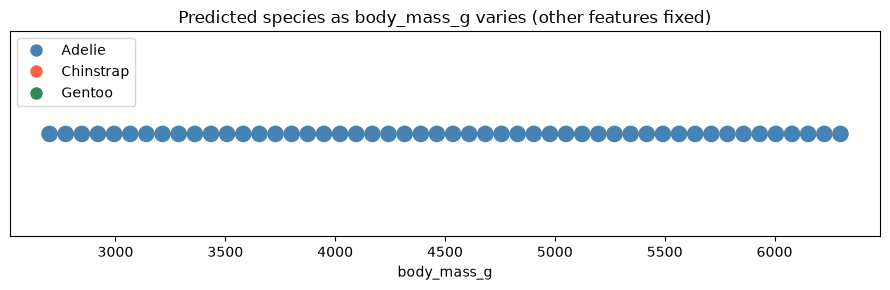

2026-08-12 15:38:56 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [12]:
def sweep_feature3(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep body_mass_g.
BASE: dict[str, Any] = BASELINES[0]
body_mass = list(np.linspace(2700, 6300, 50))
df_sweep = sweep_feature3(BASE, "body_mass_g", body_mass)

LOG.info("body_mass_g sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
sex = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["body_mass_g"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("body_mass_g")
plt.yticks([])
plt.title("Predicted species as body_mass_g varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

In [11]:
df: pd.DataFrame = sns.load_dataset("penguins")
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## Task: Interpret and Extend Section 3

**Required: Run and interpret:**

Run the sweep above and answer in your notebook (a markdown cell is fine):

1. At what value of `bill_length_mm` does the prediction first shift away from Adelie? - It switches between 42 and 43 to chinstrap. 
2. Does it shift again? To which species? - No, it does not shift again. 
3. Does this boundary make sense given what you know about penguins? - Yes and no. It makes sense that different types of penguins have different bill lengths as they are different sizes, but I don't understand why it never changed to gentoo. I changed the range and the num value, number of equally spaced paced points, multiple times I never got gentoo to show up. When I looked up a gentoo online it was larger than the other two, so I'm not sure why this is happening. 

**Optional: Extend for deeper insight:**

Try one or more of the following and add your chart and interpretation:

- Sweep a different feature (`bill_depth_mm`, `flipper_length_mm`, or `body_mass_g`)
  using the same `sweep_feature()` function. Which feature produces the sharpest boundary?

bill_depth_mm produced a boundary, while flipper_length_mm and body_mass_g did not. This means either I did something wrong in my code or, since bill_depth_mm was the most important feature according to our previous work, it was the only feature with enough distinction between the species to create a boundary. 

## Section 4. Prediction Grid

```text
ANALYST CHOICE
Vary two features together and visualize the 2D decision surface.
Choose the two features you think matter most based on Section 3.
```

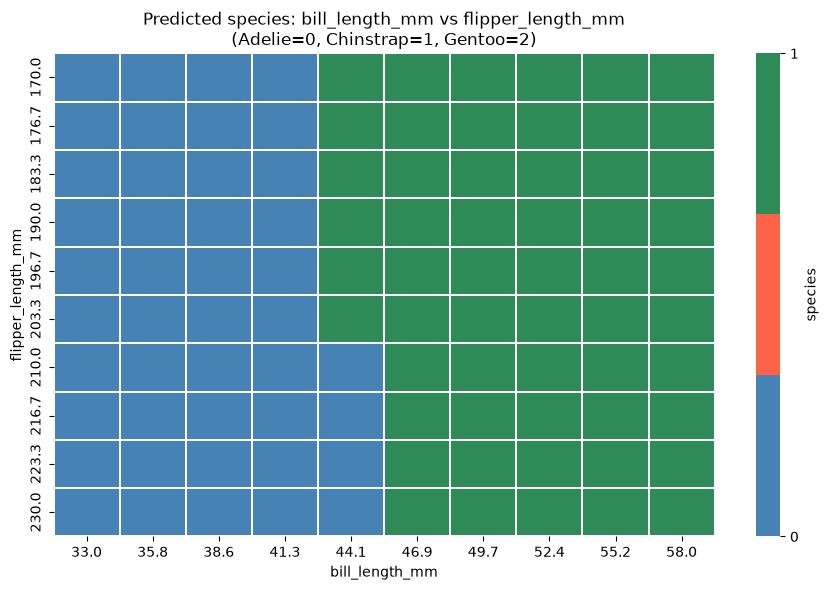

2026-08-12 15:46:19 | INFO | M07 | ANALYST CHOICE: What does the boundary shape tell you about the model?


In [15]:
# === Section 4. Prediction Grid ===

# CUSTOM: adjust ranges based on your investigation in Section 3.
bill_length_values = list(np.linspace(33, 58, 10))
flipper_length_values = list(np.linspace(170, 230, 10))

rows = []
for bl in bill_length_values:
    for fl in flipper_length_values:
        payload = {**BASE, "bill_length_mm": bl, "flipper_length_mm": fl}
        rows.append(
            {
                "bill_length_mm": round(bl, 1),
                "flipper_length_mm": round(fl, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)

pivot = df_grid.pivot(
    index="flipper_length_mm",
    columns="bill_length_mm",
    values="species_int",
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["steelblue", "tomato", "seagreen"],
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_length_mm vs flipper_length_mm\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()
plt.show()

LOG.info("ANALYST CHOICE: What does the boundary shape tell you about the model?")

## Section 5. Edge Cases

```text
ANALYST CHOICE
What happens with unusual or invalid inputs?
A robust API should handle bad input gracefully.
Decide if this one does.
```

In [16]:
# === Section 5. Edge Cases ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<22} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-08-13 15:17:27 | INFO | M07 | Edge case results:
2026-08-13 15:17:27 | INFO | M07 |   missing feature        -> ERROR: 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 15:17:27 | INFO | M07 |   extreme bill length    -> Adelie
2026-08-13 15:17:28 | INFO | M07 |   very large bill        -> Chinstrap
2026-08-13 15:17:28 | INFO | M07 |   negative value         -> Adelie
2026-08-13 15:17:28 | INFO | M07 |   zero body mass         -> Adelie
2026-08-13 15:17:28 | INFO | M07 | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


## Section 6. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [21]:
# === Section 6. Summary ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("========================")


summarize()

2026-08-13 19:01:38 | INFO | M07 | ========================
2026-08-13 19:01:38 | INFO | M07 | SUMMARY
2026-08-13 19:01:38 | INFO | M07 | ========================
2026-08-13 19:01:38 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 19:01:38 | INFO | M07 | ========================


### Narrative

Summarize your work in this Markdown cell in your notebook.

Investigations completed:

1. Baseline predictions confirmed
2. Feature sensitivity sweep (bill_length_mm)
3. Prediction grid (bill_length_mm x flipper_length_mm)
4. Edge case testing

### Conclusions

This is SUPERVISED learning (because the model was trained with a target).

The target is `species`, a category column, so the model performs classification.

We investigated the model's behavior from the outside by varying inputs and observing predictions.

### Next Steps

Next steps would include assessing and changing the model so that it was correctly responding to all of the edge boundaries. 
I would also do more work to see if it were possible to get a boundary shirt between all three species of penguins on the features.
